# TCS Securities Lending & Borrowing (SLB) Market Analysis

### Finance Data Cleaning & Exploratory Analysis Project

This project analyzes historical **TCS Securities Lending & Borrowing (SLB)** trading data.

Focuses on:
- Data cleaning
- Data transformation
- Exploratory data analysis
- Financial-market visualizations



## 1. Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


## 2. Load the Dataset




In [ ]:
FILE_NAME = "Quote-SLB-TCS-EQ-9-03-2026-to-9-09-2026.csv"

if not os.path.exists(FILE_NAME):
    try:
        from google.colab import files
        print(f"Please upload {FILE_NAME}")
        uploaded = files.upload()
        if FILE_NAME not in uploaded:
            csv_files = [name for name in uploaded if name.lower().endswith(".csv")]
            if not csv_files:
                raise FileNotFoundError("No CSV file was uploaded.")
            FILE_NAME = csv_files[0]
    except ImportError:
        raise FileNotFoundError(
            f"{FILE_NAME} was not found. Put the CSV in the same folder as this notebook."
        )

raw_df = pd.read_csv(FILE_NAME)

print("Dataset shape:", raw_df.shape)
raw_df.head()


Dataset shape: (230, 14)


,Symbol,Date,Settlement Date,Series,Open Price,High Price,Low Price,PREV. CLOSE,Close Price,52 weeks High,52 weeks Low,Total Traded Quantity,Total Traded Value in Rs.,Number of Trades
0,TCS,09-SEP-2026,06-OCT-2026,XO,1.50,1.50,1.47,0.01,1.49,5.00,0.01,"1,350","2,015.45",8
1,TCS,09-SEP-2026,03-NOV-2026,XN,1.00,1.00,1.00,0.50,1.00,2.95,0.45,700,700.00,4
2,TCS,07-SEP-2026,06-OCT-2026,XO,0.01,0.01,0.01,0.50,0.01,5.00,0.01,127,1.27,1
3,TCS,03-SEP-2026,06-OCT-2026,XO,0.50,0.50,0.50,0.50,0.50,5.00,0.01,52,26.00,1
4,TCS,03-SEP-2026,07-SEP-2027,X9,1.00,1.00,1.00,0.99,1.00,4.90,0.01,1,1.00,1


## 3. Inspect the Raw Data

In [ ]:
print("Rows:", raw_df.shape[0])
print("Columns:", raw_df.shape[1])

print("\nOriginal column names:")
print(raw_df.columns.tolist())

print("\nData types:")
print(raw_df.dtypes)

print("\nMissing values:")
print(raw_df.isnull().sum())


Rows: 230
Columns: 14

Original column names:
['Symbol ', 'Date ', ' Settlement Date ', 'Series ', 'Open Price ', 'High Price ', 'Low Price ', 'PREV. CLOSE ', 'Close Price ', '52 weeks High ', '52 weeks Low ', 'Total Traded Quantity ', 'Total Traded Value in Rs.', 'Number of Trades ']

Data types:
Symbol                        object
Date                          object
 Settlement Date              object
Series                        object
Open Price                   float64
High Price                   float64
Low Price                    float64
PREV. CLOSE                   object
Close Price                  float64
52 weeks High                float64
52 weeks Low                 float64
Total Traded Quantity         object
Total Traded Value in Rs.     object
Number of Trades              object
dtype: object

Missing values:
Symbol                       0
Date                         0
 Settlement Date             0
Series                       0
Open Price                  

## 4. Data Cleaning




In [ ]:
df = raw_df.copy()

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Remove duplicate rows
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

# Parse date columns
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%Y", errors="coerce")
df["Settlement Date"] = pd.to_datetime(
    df["Settlement Date"], format="%d-%b-%Y", errors="coerce"
)

# Convert comma-formatted numeric columns
comma_numeric_cols = [
    "PREV. CLOSE",
    "Total Traded Quantity",
    "Total Traded Value in Rs.",
    "Number of Trades"
]

for col in comma_numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("-", np.nan)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Ensure all market-price columns are numeric
price_cols = [
    "Open Price", "High Price", "Low Price", "PREV. CLOSE",
    "Close Price", "52 weeks High", "52 weeks Low"
]

for col in price_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Duplicate rows removed:", duplicates_before)
print("Cleaned shape:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

df.head()


Duplicate rows removed: 0
Cleaned shape: (230, 14)

Missing values after cleaning:
Symbol                       0
Date                         0
Settlement Date              0
Series                       0
Open Price                   0
High Price                   0
Low Price                    0
PREV. CLOSE                  0
Close Price                  0
52 weeks High                0
52 weeks Low                 0
Total Traded Quantity        0
Total Traded Value in Rs.    0
Number of Trades             0
dtype: int64


,Symbol,Date,Settlement Date,Series,Open Price,High Price,Low Price,PREV. CLOSE,Close Price,52 weeks High,52 weeks Low,Total Traded Quantity,Total Traded Value in Rs.,Number of Trades
0,TCS,2026-09-09,2026-10-06,XO,1.50,1.50,1.47,0.01,1.49,5.00,0.01,1350,2015.45,8
1,TCS,2026-09-09,2026-11-03,XN,1.00,1.00,1.00,0.50,1.00,2.95,0.45,700,700.00,4
2,TCS,2026-09-07,2026-10-06,XO,0.01,0.01,0.01,0.50,0.01,5.00,0.01,127,1.27,1
3,TCS,2026-09-03,2026-10-06,XO,0.50,0.50,0.50,0.50,0.50,5.00,0.01,52,26.00,1
4,TCS,2026-09-03,2027-09-07,X9,1.00,1.00,1.00,0.99,1.00,4.90,0.01,1,1.00,1


## 5. Basic Summary

In [ ]:
print("Security:", df["Symbol"].mode().iloc[0])
print("Number of records:", len(df))
print("Unique trading dates:", df["Date"].nunique())
print("Unique SLB series:", df["Series"].nunique())
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())

summary_cols = [
    "Open Price", "High Price", "Low Price", "Close Price",
    "Total Traded Quantity", "Total Traded Value in Rs.",
    "Number of Trades"
]

df[summary_cols].describe().round(2)


Security: TCS
Number of records: 230
Unique trading dates: 110
Unique SLB series: 17
Date range: 2026-03-09 to 2026-09-09


,Open Price,High Price,Low Price,Close Price,Total Traded Quantity,Total Traded Value in Rs.,Number of Trades
count,230.00,230.00,230.00,230.00,230.00,230.00,230.00
mean,2.57,3.39,1.93,2.60,70082.00,218293.67,120.80
std,10.27,10.41,9.86,9.98,173102.17,616224.62,364.16
min,0.01,0.01,0.01,0.01,1.00,0.10,1.00
25%,0.94,1.00,0.50,0.98,295.75,276.45,3.00
50%,1.23,2.00,1.00,1.50,4549.50,8600.64,12.00
75%,2.75,3.75,2.00,3.00,46560.75,114445.41,87.50
max,150.00,150.00,150.00,150.00,1288587.00,4855822.97,4207.00


## 6. Most Active SLB Series




In [ ]:
series_summary = (
    df.groupby("Series")
      .agg(
          Records=("Series", "size"),
          Total_Quantity=("Total Traded Quantity", "sum"),
          Total_Value=("Total Traded Value in Rs.", "sum"),
          Total_Trades=("Number of Trades", "sum")
      )
      .sort_values("Total_Quantity", ascending=False)
)

series_summary.head(10)


,Records,Total_Quantity,Total_Value,Total_Trades
Series,,,,
X8,30,3772581,13246234.82,2872
X9,26,3162385,10208949.78,6436
X6,24,2397559,7260239.91,2549
X7,33,2210476,7028471.95,4890
X5,21,1251689,3010719.22,2988
G1,13,1130732,4082453.78,3816
L1,18,723927,2222039.43,1412
U1,12,523544,1545305.06,830
S1,12,377694,479123.55,679


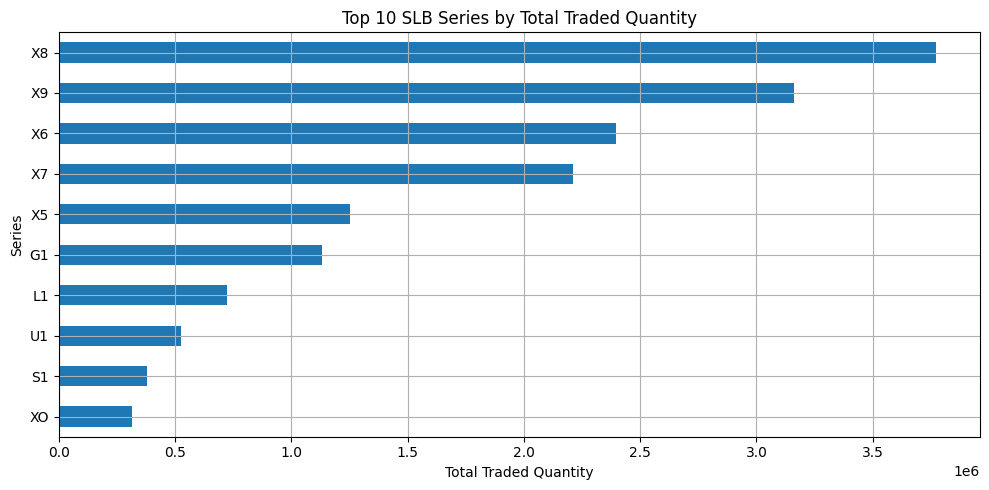

In [ ]:
top_series = series_summary["Total_Quantity"].head(10).sort_values()

top_series.plot(kind="barh")
plt.title("Top 10 SLB Series by Total Traded Quantity")
plt.xlabel("Total Traded Quantity")
plt.ylabel("Series")
plt.tight_layout()
plt.show()


## 7. Build a Daily Activity Table




In [ ]:
daily = (
    df.groupby("Date")
      .agg(
          Total_Quantity=("Total Traded Quantity", "sum"),
          Total_Value=("Total Traded Value in Rs.", "sum"),
          Total_Trades=("Number of Trades", "sum"),
          Active_Series=("Series", "nunique")
      )
      .sort_index()
)

daily["Weighted_Avg_Price"] = (
    daily["Total_Value"] / daily["Total_Quantity"]
).replace([np.inf, -np.inf], np.nan)

daily.head()


,Total_Quantity,Total_Value,Total_Trades,Active_Series,Weighted_Avg_Price
Date,,,,,
2026-03-09,13,0.13,2,1,0.010000
2026-03-10,30,3.00,1,1,0.100000
2026-03-17,1,0.11,1,1,0.110000
2026-03-19,635,484.62,4,1,0.763181
2026-03-20,268,590.74,4,2,2.204254


## 8. Daily SLB Traded Quantity

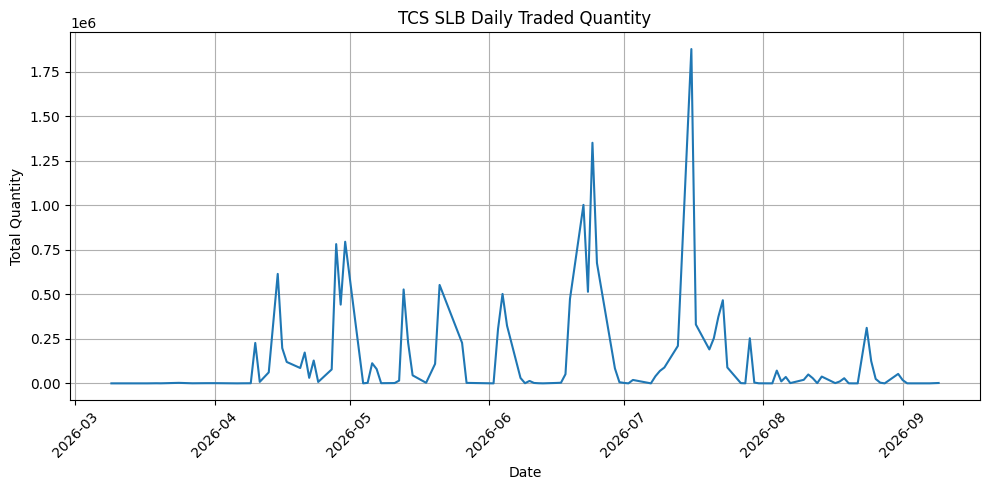

In [ ]:
plt.plot(daily.index, daily["Total_Quantity"])
plt.title("TCS SLB Daily Traded Quantity")
plt.xlabel("Date")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 9. Daily Traded Value

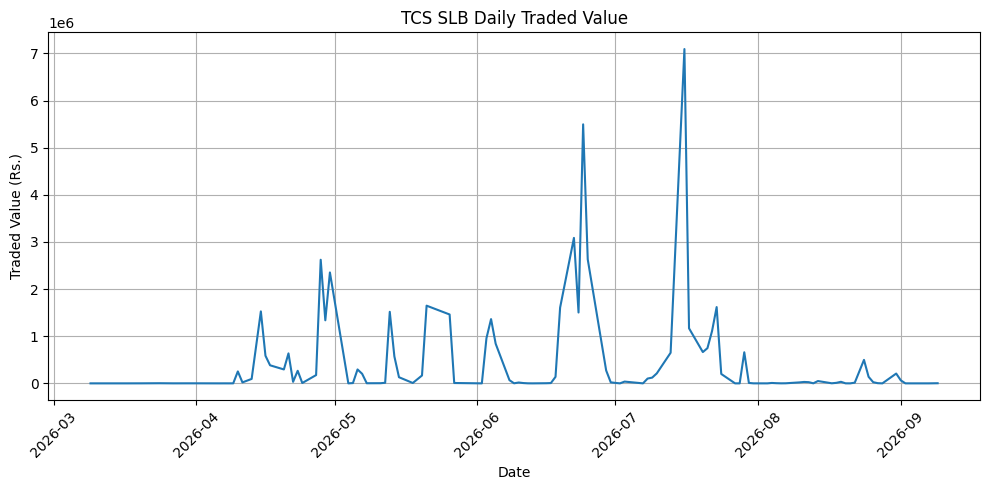

In [ ]:
plt.plot(daily.index, daily["Total_Value"])
plt.title("TCS SLB Daily Traded Value")
plt.xlabel("Date")
plt.ylabel("Traded Value (Rs.)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 10. Weighted Average SLB Price



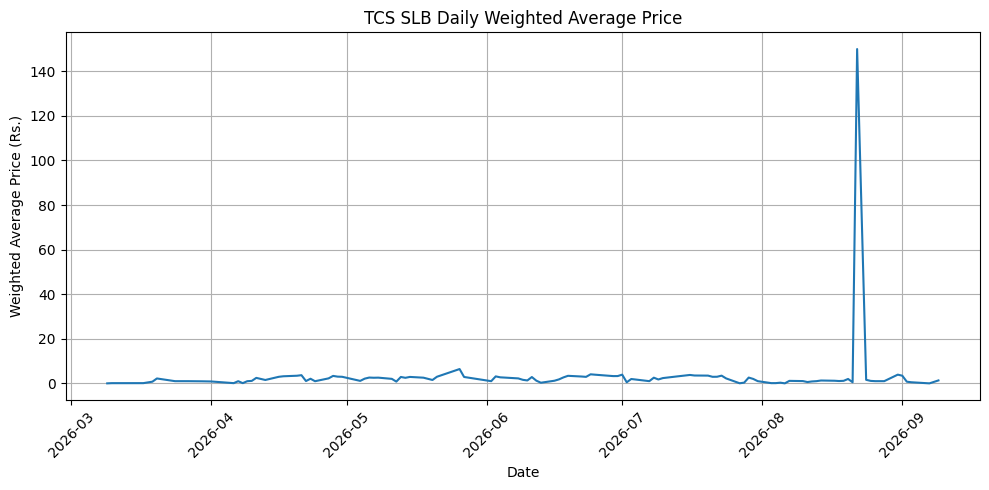

In [ ]:
plt.plot(daily.index, daily["Weighted_Avg_Price"])
plt.title("TCS SLB Daily Weighted Average Price")
plt.xlabel("Date")
plt.ylabel("Weighted Average Price (Rs.)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 11. Highest Activity Days

In [ ]:
top_volume_days = (
    daily.sort_values("Total_Quantity", ascending=False)
         [["Total_Quantity", "Total_Value", "Total_Trades", "Active_Series", "Weighted_Avg_Price"]]
         .head(10)
)

top_volume_days


,Total_Quantity,Total_Value,Total_Trades,Active_Series,Weighted_Avg_Price
Date,,,,,
2026-07-16,1876287,7094018.78,6563,3,3.780881
2026-06-24,1350324,5496297.90,1704,3,4.070355
2026-06-22,1001708,3086562.47,717,3,3.081300
2026-04-30,794796,2353328.30,440,1,2.960921
2026-04-28,781599,2623050.64,993,3,3.356006
2026-06-25,675478,2631557.98,547,3,3.895846
2026-04-15,614325,1527000.28,986,3,2.485655
2026-05-21,552426,1648483.67,464,2,2.984081
2026-05-13,527137,1518255.91,837,3,2.880192


## 12. Most Valuable Trading Days

In [ ]:
top_value_days = (
    daily.sort_values("Total_Value", ascending=False)
         [["Total_Value", "Total_Quantity", "Total_Trades", "Active_Series", "Weighted_Avg_Price"]]
         .head(10)
)

top_value_days


,Total_Value,Total_Quantity,Total_Trades,Active_Series,Weighted_Avg_Price
Date,,,,,
2026-07-16,7094018.78,1876287,6563,3,3.780881
2026-06-24,5496297.90,1350324,1704,3,4.070355
2026-06-22,3086562.47,1001708,717,3,3.081300
2026-06-25,2631557.98,675478,547,3,3.895846
2026-04-28,2623050.64,781599,993,3,3.356006
2026-04-30,2353328.30,794796,440,1,2.960921
2026-05-21,1648483.67,552426,464,2,2.984081
2026-07-23,1618612.07,466526,616,2,3.469500
2026-06-19,1608305.16,473803,234,3,3.394460


### 13. Relationship Between Market Activity Measures

In [ ]:
analysis_cols = [
    "Total_Quantity",
    "Total_Value",
    "Total_Trades",
    "Active_Series",
    "Weighted_Avg_Price"
]

correlation = daily[analysis_cols].corr().round(2)
correlation


,Total_Quantity,Total_Value,Total_Trades,Active_Series,Weighted_Avg_Price
Total_Quantity,1.00,0.98,0.83,0.35,-0.00
Total_Value,0.98,1.00,0.84,0.33,0.00
Total_Trades,0.83,0.84,1.00,0.27,-0.00
Active_Series,0.35,0.33,0.27,1.00,-0.09
Weighted_Avg_Price,-0.00,0.00,-0.00,-0.09,1.00


## 14. Distribution of Weighted SLB Prices

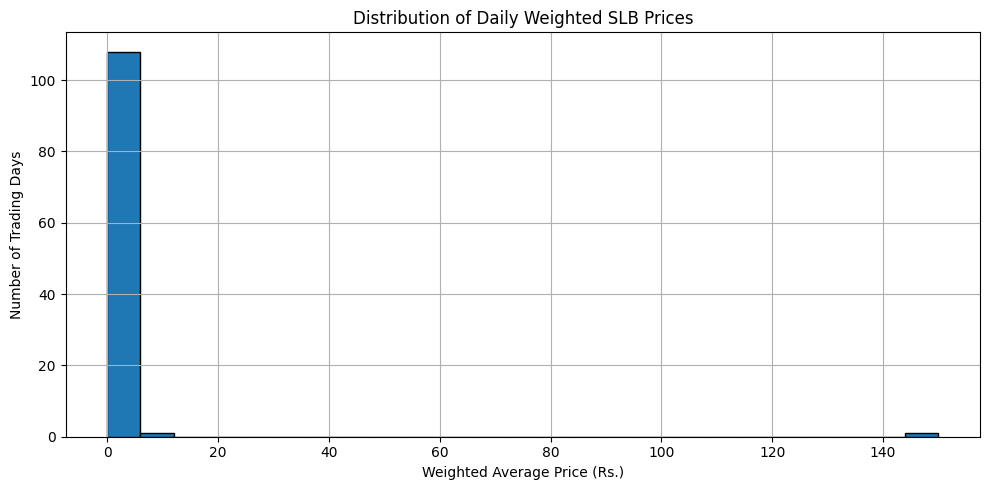

Mean weighted SLB price: 3.24
Median weighted SLB price: 1.88


In [ ]:
plt.hist(daily["Weighted_Avg_Price"].dropna(), bins=25, edgecolor="black")
plt.title("Distribution of Daily Weighted SLB Prices")
plt.xlabel("Weighted Average Price (Rs.)")
plt.ylabel("Number of Trading Days")
plt.tight_layout()
plt.show()

print("Mean weighted SLB price:", round(daily["Weighted_Avg_Price"].mean(), 2))
print("Median weighted SLB price:", round(daily["Weighted_Avg_Price"].median(), 2))


## 15. Key Findings Generated from the Data

In [ ]:
highest_qty_day = daily["Total_Quantity"].idxmax()
highest_val_day = daily["Total_Value"].idxmax()
highest_price_day = daily["Weighted_Avg_Price"].idxmax()

print("Highest quantity day:")
print(highest_qty_day.date(), "-", int(daily.loc[highest_qty_day, "Total_Quantity"]))

print("\nHighest traded value day:")
print(highest_val_day.date(), "- Rs.", round(daily.loc[highest_val_day, "Total_Value"], 2))

print("\nHighest weighted average SLB price day:")
print(highest_price_day.date(), "- Rs.", round(daily.loc[highest_price_day, "Weighted_Avg_Price"], 2))

print("\nOverall traded quantity:", int(daily["Total_Quantity"].sum()))
print("Overall traded value: Rs.", round(daily["Total_Value"].sum(), 2))
print("Overall number of trades:", int(daily["Total_Trades"].sum()))


Highest quantity day:
2026-07-16 - 1876287

Highest traded value day:
2026-07-16 - Rs. 7094018.78

Highest weighted average SLB price day:
2026-08-22 - Rs. 150.0

Overall traded quantity: 16118861
Overall traded value: Rs. 50207544.14
Overall number of trades: 27784


## 16. Conclusion

This project cleaned and analyzed historical TCS Securities Lending & Borrowing market data.

### What the analysis demonstrates
- Cleaning financial-market CSV data
- Handling Indian comma-formatted numeric values
- Parsing trading and settlement dates
- Aggregating multiple settlement series into daily activity
- Measuring traded quantity, traded value, and number of trades
- Calculating a weighted average SLB price
- Identifying high-activity trading days
- Studying relationships among trading activity variables

